## CALIFORNIA HOUSING PRICES

This workbook demonstrates usage of **Multivariate Regression** to predict mdeia district housing prices so as to make smart investments.

In [1]:
import opendatasets as od

In [2]:
od.download_kaggle_dataset('https://www.kaggle.com/datasets/shibumohapatra/house-price',data_dir="./datasets")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username:Your Kaggle Key:Dataset URL: https://www.kaggle.com/datasets/shibumohapatra/house-price


100%|██████████| 387k/387k [00:01<00:00, 356kB/s]

In [3]:
import pandas as pd
import numpy as np
import os

In [4]:
data_df = pd.read_csv('./datasets/house-price/1553768847-housing.csv')

In [5]:
data_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200


In [6]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   ocean_proximity     20640 non-null  object 
 9   median_house_value  20640 non-null  int64  
dtypes: float64(4), int64(5), object(1)
memory usage: 1.6+ MB


In [7]:
data_df['total_bedrooms'].isnull().sum()

207

From above we observe that there exists 207 districts with null entries under **total_bedrooms**.

In [8]:
import matplotlib.pyplot as plt

In [9]:
data_df['ocean_proximity'].value_counts()

<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: ocean_proximity, dtype: int64

In [10]:
data_df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


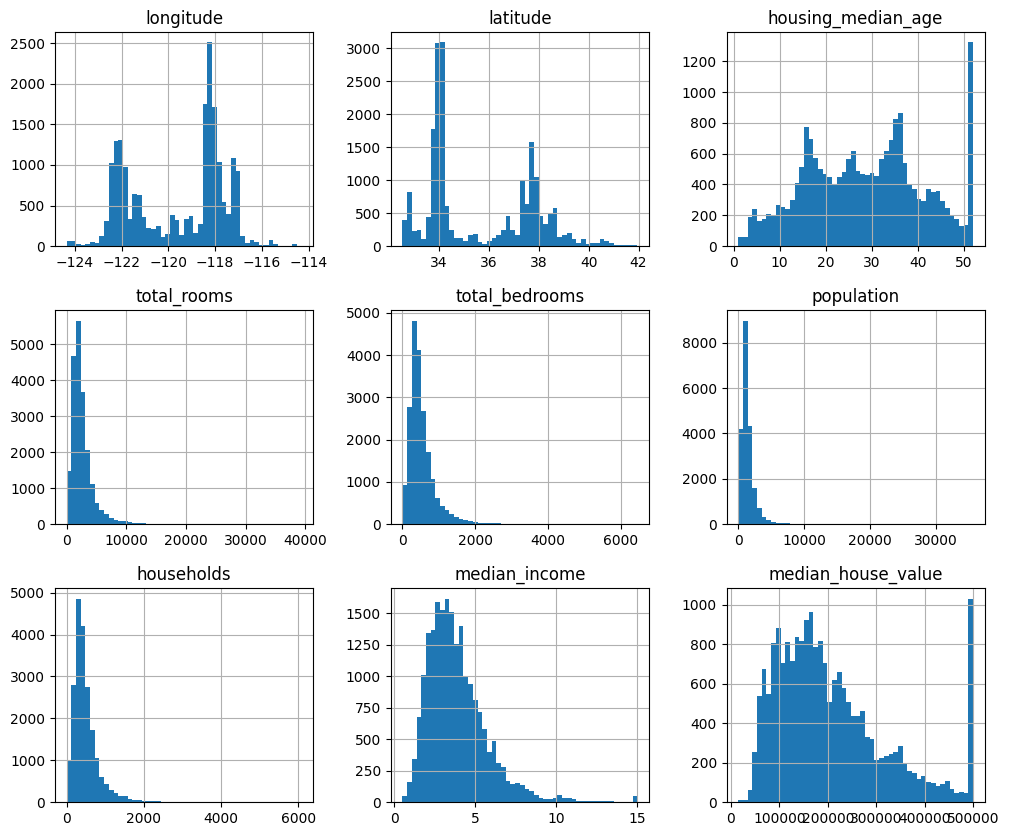

In [11]:
data_df.hist(bins=50,figsize=(12,10))
plt.show()

### SPLITTING TRAIN AND TEST SET

Splitting data into test/train set is crucial since care is to be taken that the test-set remains largely consistent i.e. even with dataset shrink or growth the instances in test-set remains consistent throughout. 
If the above does not happen then overtime the learning algorithm sees all the instances both in train and test, performs well on the test-set but fails to generalize well on new unseen instances. 

Suppose the **median_income** is an important factor that determines the **median_housing_price** in a district. In that situation one must ensure that test-set is representative of various categories of incomes in the whole dataset. 
Here we use **STRATIFIED SAMPLING**.

In [12]:
data_df['income_cat'] = pd.cut(data_df['median_income'],bins=[0.,1.5,3.0,4.5,6.,np.inf],labels=[1,2,3,4,5])

In [13]:
data_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value,income_cat
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600,5
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500,5
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100,5
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300,4
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200,3


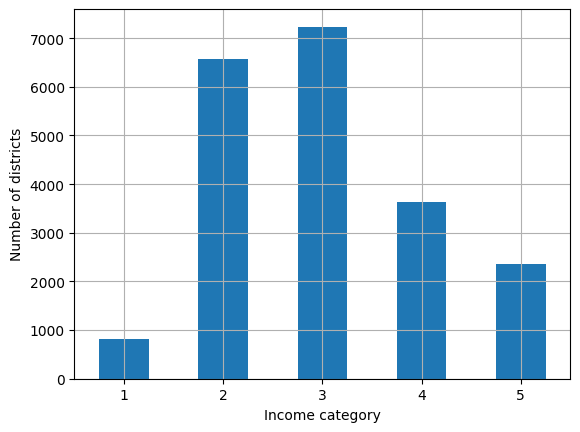

In [14]:
data_df['income_cat'].value_counts().sort_index().plot.bar(rot=0,grid=True)
plt.xlabel('Income category')
plt.ylabel('Number of districts')
plt.show()

### PERFORM STRATIFIED SAMPLING
Since the total dataset is relatively small for an ML model to eliminate **sampling bias** we perform **stratified sampling** such that the test-set closely resembles the entire population otherwise the model gets biassed blinded to certain patterns in the data.

In [15]:
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits=10,test_size=0.2,random_state=42)
strat_splits = []

for train_idx,test_idx in splitter.split(data_df,data_df['income_cat']):
    strat_train_set_n = data_df.iloc[train_idx]
    strat_test_set_n = data_df.iloc[test_idx]
    strat_splits.append([strat_train_set_n,strat_test_set_n])


strat_train_set,strat_test_set = strat_splits[0]

### CHECKING RESULT OF STRATIFIED SAMPLING

In [16]:
strat_test_set['income_cat'].value_counts()/len(strat_test_set)

3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: income_cat, dtype: float64

In [17]:
data_df['income_cat'].value_counts()/len(data_df)

3    0.350581
2    0.318847
4    0.176308
5    0.114438
1    0.039826
Name: income_cat, dtype: float64

As can be observed from above with **STRATIFIED SAMPLING** the test-set contains similar representation of the entire population.

In [18]:
strat_test_set.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value,income_cat
5241,-118.39,34.12,29,6447,1012.0,2184,960,8.2816,<1H OCEAN,500001,5
17352,-120.42,34.89,24,2020,307.0,855,283,5.0099,<1H OCEAN,162500,4
3505,-118.45,34.25,36,1453,270.0,808,275,4.3839,<1H OCEAN,204600,3
7777,-118.10,33.91,35,1653,325.0,1072,301,3.2708,<1H OCEAN,159700,3
14155,-117.07,32.77,38,3779,614.0,1495,614,4.3529,NEAR OCEAN,184000,3


In [19]:
strat_test_set.drop(columns=['income_cat'],inplace=True)
strat_train_set.drop(columns=['income_cat'],inplace=True)

/var/folders/_d/d0_pf6hn3t5gl_r_tykfvcxh0000gn/T/ipykernel_8523/2289387165.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  strat_test_set.drop(columns=['income_cat'],inplace=True)
/var/folders/_d/d0_pf6hn3t5gl_r_tykfvcxh0000gn/T/ipykernel_8523/2289387165.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  strat_train_set.drop(columns=['income_cat'],inplace=True)


In [20]:
housing = strat_train_set.copy()

### VISUALIZE GEOGRAPHICAL DATA
Since the data contains longitudes & latitudes of districts we visualize it.

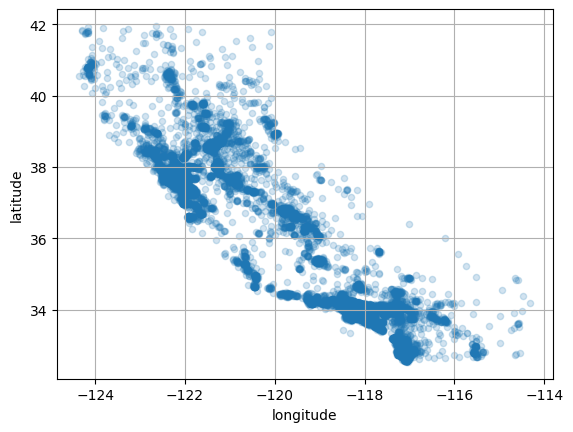

In [21]:
housing.plot(kind='scatter',x='longitude',y='latitude',grid=True,alpha=0.2)
plt.show()

Now we plot the above but with additional features such as the radii of each bubble now represents **population** and its color **median_house_price** resprectively.

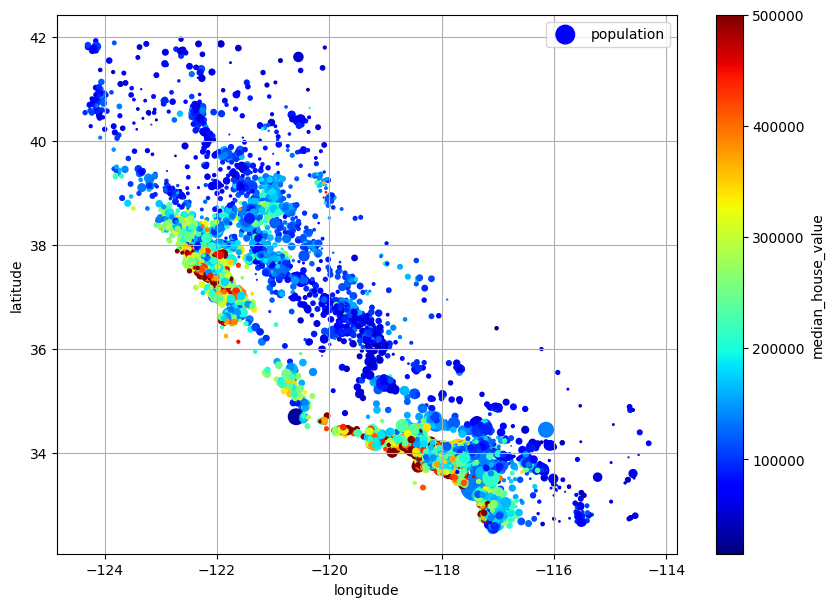

In [22]:
housing.plot(kind='scatter',x='longitude',y='latitude',grid=True,s=housing['population']/100,c='median_house_value',colormap='jet',colorbar=True,legend=True,figsize=(10,7),sharex=False,label='population')
plt.show()

### COMPUTE CORRELATIONS
Since the dataset isn't too large we compute the standard correlation coefficient between every pair of attributes.

In [23]:
corr_matrix = housing.corr()

/var/folders/_d/d0_pf6hn3t5gl_r_tykfvcxh0000gn/T/ipykernel_8523/2466220658.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = housing.corr()


Now we check which all attributes correlates the most with **median_housing_value**.

In [24]:
corr_matrix['median_house_value'].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687151
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
population           -0.026882
longitude            -0.047466
latitude             -0.142673
Name: median_house_value, dtype: float64

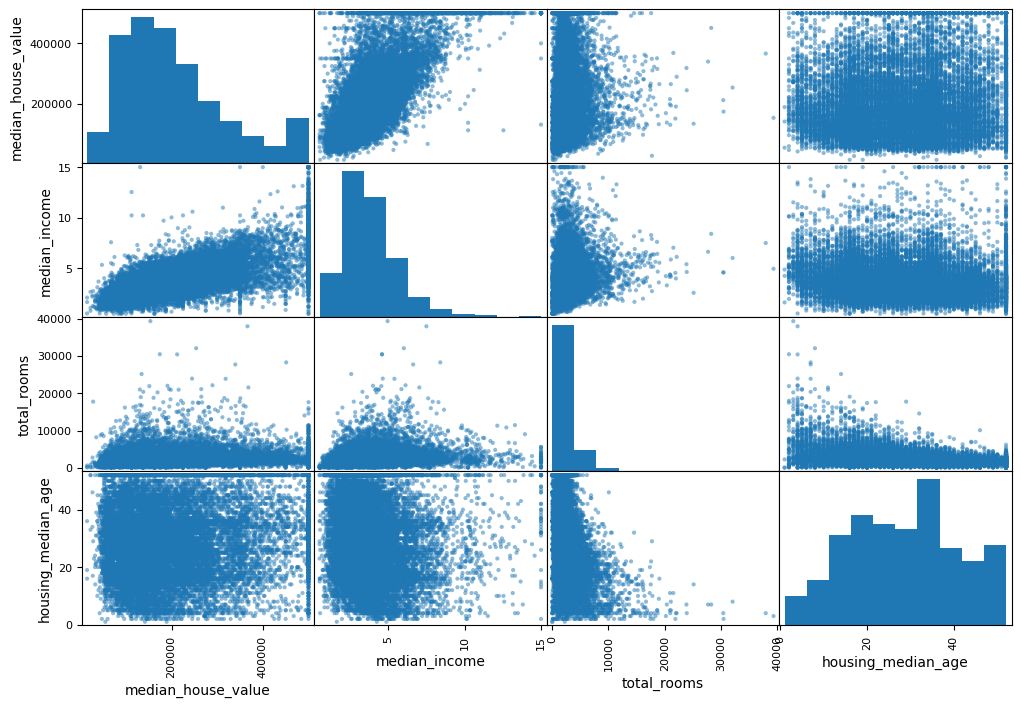

In [25]:
from pandas.plotting import scatter_matrix

attributes = ['median_house_value','median_income','total_rooms','housing_median_age']
scatter_matrix(housing[attributes],figsize=(12,8))
plt.show()

From above we observe that there exists a strong positive correlation between **median_house_price** & **median_income**. Hence we look at their scatter-plot more closely below.

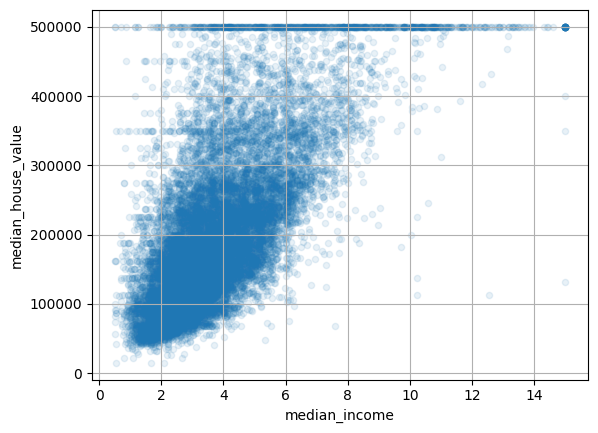

In [26]:
housing.plot(kind='scatter',x='median_income',y='median_house_value',grid=True,alpha=0.1)
plt.show()

From above scatter plot we observe that there exists numerous straight lines that shows capped **median_house_value** viz $500000,$450000,$350000 etc. These are data-artifacts introduced due to the way the data was collated. 
With these fed to the learning algorithm following could happen:
1. The ML model could pick up the wrong pattern in data and hence may fail to generalise well when tested on real-world examples. In real-world house prices could go as high as $700k,$1M+. 

Hence we remove districts with apparent capped values from the dataset prior to feeding the signal to model.

In [27]:
housing['median_house_value'].value_counts().sort_index(ascending=False)

500001    786
500000     23
499100      1
499000      1
498800      1
         ... 
27500       1
26900       1
26600       1
22500       3
14999       3
Name: median_house_value, Length: 3669, dtype: int64

Let's remove districts with **median_house_value** of $500001 to make the train set less biased.

In [28]:
housing = housing[housing['median_house_value']<500001]

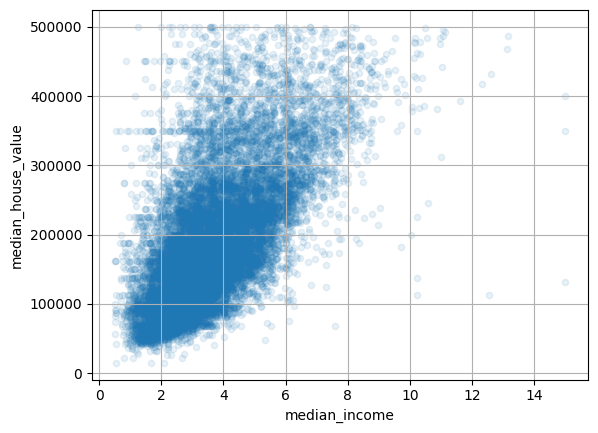

In [29]:
housing.plot(kind='scatter',x='median_income',y='median_house_value',grid=True,alpha=0.1)
plt.show()

From above scatter-plot we observe that data now looks better.

In [30]:
housing.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity', 'median_house_value'],
      dtype='object')

### EXPERIMENT WITH ATTRIBUTE COMBINATIONS
In ML attribute combinations play an important role. Some attributes may not look important as is but when changed and looked at presents a very different picture. 

For instance **Total_rooms** indicate no correlation with the target variable **median_house_value** but **Total_rooms_per_household** could. Similar is the case with **Total_population**, we may want to look at **Total_population_per_household** in a district to determine the median house price.

In [31]:
housing['rooms_per_household'] = housing['total_rooms']/housing['households']
housing['population_per_household'] = housing['population']/housing['households']
housing['bedroom_ratio'] = housing['total_bedrooms']/housing['total_rooms']
housing['bedroom_per_household'] = housing['total_bedrooms']/housing['households']

/var/folders/_d/d0_pf6hn3t5gl_r_tykfvcxh0000gn/T/ipykernel_8523/1648425942.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  housing['rooms_per_household'] = housing['total_rooms']/housing['households']
/var/folders/_d/d0_pf6hn3t5gl_r_tykfvcxh0000gn/T/ipykernel_8523/1648425942.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  housing['population_per_household'] = housing['population']/housing['households']
/var/folders/_d/d0_pf6hn3t5gl_r_tykfvcxh0000gn/T/ipykernel_8523/1648425942.py:3: SettingWithCopyWa

In [32]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value,rooms_per_household,population_per_household,bedroom_ratio,bedroom_per_household
12655,-121.46,38.52,29,3873,797.0,2237,706,2.1736,INLAND,72100,5.485836,3.168555,0.205784,1.128895
15502,-117.23,33.09,7,5320,855.0,2015,768,6.3373,NEAR OCEAN,279600,6.927083,2.623698,0.160714,1.113281
2908,-119.04,35.37,44,1618,310.0,667,300,2.8750,INLAND,82700,5.393333,2.223333,0.191595,1.033333
14053,-117.13,32.75,24,1877,519.0,898,483,2.2264,NEAR OCEAN,112500,3.886128,1.859213,0.276505,1.074534
20496,-118.70,34.28,27,3536,646.0,1837,580,4.4964,<1H OCEAN,238300,6.096552,3.167241,0.182692,1.113793


With the above derived attributes computed we now see how the relationship looks like with the target **median_house_value**.

In [33]:
housing_corr_matrix = housing.corr()

/var/folders/_d/d0_pf6hn3t5gl_r_tykfvcxh0000gn/T/ipykernel_8523/1824685227.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  housing_corr_matrix = housing.corr()


In [34]:
housing_corr_matrix['median_house_value'].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.640366
total_rooms                 0.143254
rooms_per_household         0.105576
households                  0.094826
housing_median_age          0.073886
total_bedrooms              0.073796
population                  0.010537
population_per_household   -0.019638
longitude                  -0.043859
bedroom_per_household      -0.058523
latitude                   -0.150194
bedroom_ratio              -0.220929
Name: median_house_value, dtype: float64

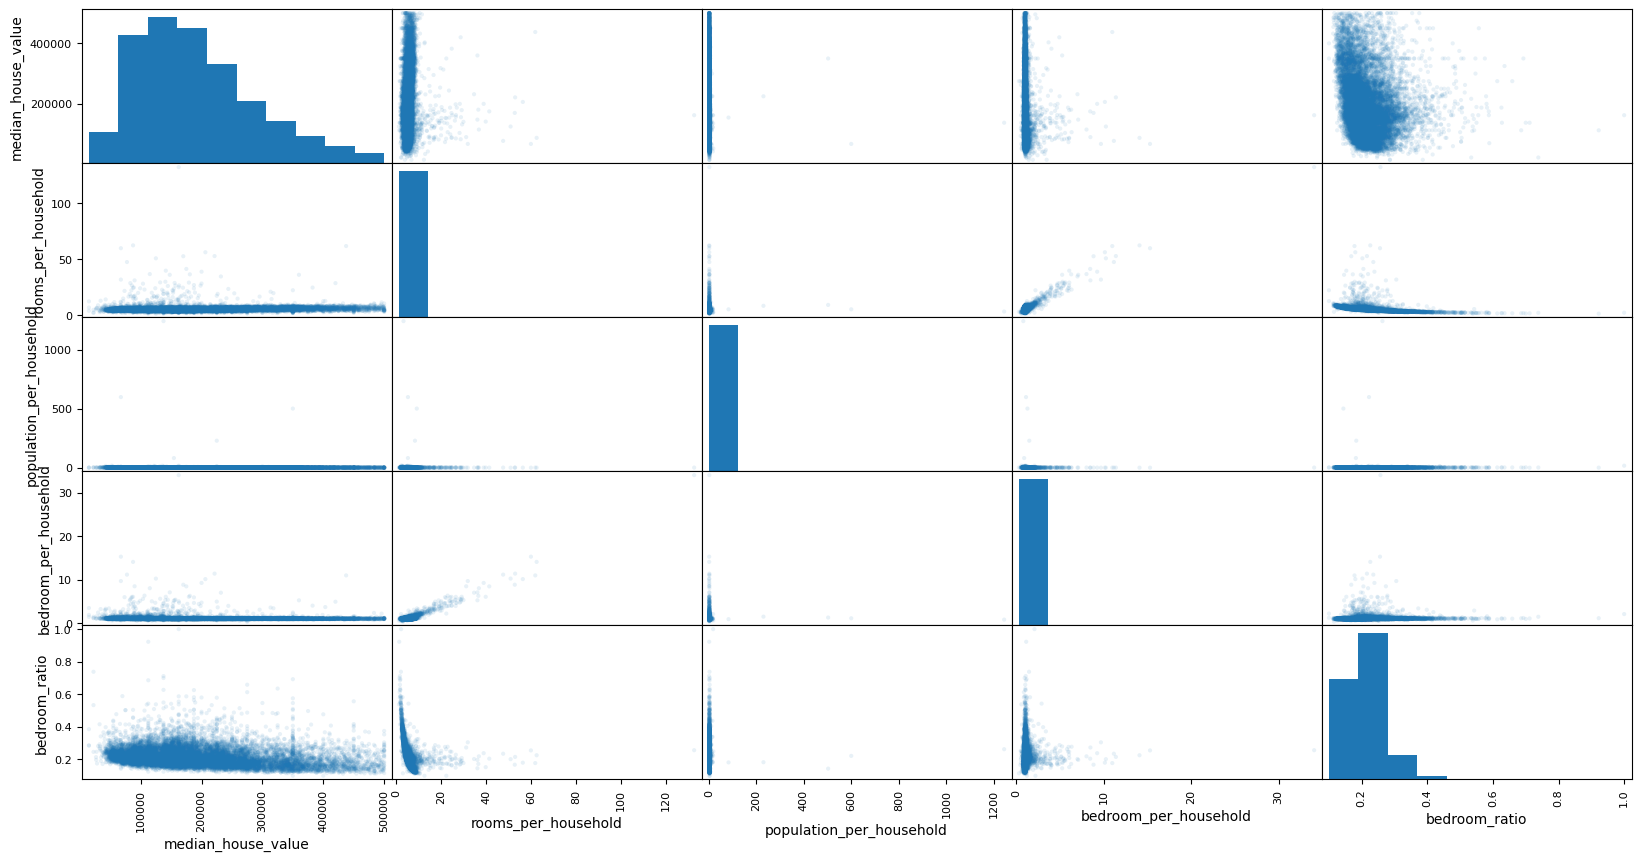

In [35]:
new_attributes = ['median_house_value','rooms_per_household','population_per_household','bedroom_per_household','bedroom_ratio']
scatter_matrix(housing[new_attributes],figsize=(20,10),alpha=0.1)
plt.show()

### PREPARE DATA FOR ML MODEL
We use a clean training set here and before we apply transformations we segregate the features from the label.

In [36]:
housing = strat_train_set.drop('median_house_value',axis=1)
housing_label = strat_train_set['median_house_value']

### CLEAN DATA
We noticed that **Total_bedrooms** attribute has a couple of NA values. ML algorithms cannot handle NA values & hence one has 3 options, 
1. Remove corresponding entries
2. Remove entire attribute
3. Replace NA values with either mean,median,mode etc. This is called **Imputation**. 

We use option 3 above.

In [37]:
from sklearn.impute import SimpleImputer

In [38]:
imputer = SimpleImputer(strategy='median')

Since **imputer** above only works for numerical attributes we copy entries pertaining to numerical attributes only which we pass to the **imputer** later on.

In [39]:
housing_num = housing.select_dtypes(include=np.number)

In [40]:
imputer.fit(housing_num)

SimpleImputer(strategy='median')

Above the **imputer** computes the median value of each of the attribute passed & stores it in an instance variable **statistics_**.

In [41]:
imputer.statistics_

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

In [42]:
X = imputer.transform(housing_num)

In [43]:
housing_tr = pd.DataFrame(X,columns=housing_num.columns,index=housing_num.index)

In [44]:
housing_tr.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964


Next we convert categorical values to numbers since models only understand numbers & not text.

In [45]:
from sklearn.preprocessing import OrdinalEncoder

In [46]:
ordinal_encoder = OrdinalEncoder()

In [47]:
housing_cat = housing[['ocean_proximity']]
housing_cat.head()

,ocean_proximity
12655,INLAND
15502,NEAR OCEAN
2908,INLAND
14053,NEAR OCEAN
20496,<1H OCEAN


In [48]:
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)

In [49]:
housing_cat_encoded[:8]

array([[1.],
       [4.],
       [1.],
       [4.],
       [0.],
       [3.],
       [0.],
       [0.]])

In [50]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

The disadvantage using the previous encoding is that ML algorithms assume that near values are more similar in nature i.e. 0 & 1 are more similar rather than 0 & 4. 

In the above case 0 - <1H Ocean> & 1 - inland in no way seems similar & hence we use **ONE-HOT ENCODING** wherein at a time only one attribute remains hot(1) whilst others remain cold(0).

Had we used categories such as bad,average,good and excellent or similar other categories which holds an innate order within **ORDINAL ENCODING** would have sufficed.

In [51]:
from sklearn.preprocessing import OneHotEncoder

In [52]:
cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

In [53]:
housing_cat_1hot

<16512x5 sparse matrix of type '<class 'numpy.float64'>'
	with 16512 stored elements in Compressed Sparse Row format>

To convert the above sparse matrix to a dense form use numpy **toarray()** method.

In [54]:
housing_cat_1hot.toarray()

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       ...,
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.]])

The advantage with **One hot encoder** is that it remembers the categories it was trained on such that when model is in production it is fed exactly same features as during training. Moreover for unknown category **get_dummies** create a new attribute whereas **one-hot encoder** is smart and raises an exception unless it's function **handle_unknown** is set to **ignore** in which case it puts zero inplace of the new category.

In [55]:
df_test = pd.DataFrame({'ocean_proximity':['INLAND','NEAR BAY']})
pd.get_dummies(df_test)

,ocean_proximity_INLAND,ocean_proximity_NEAR BAY
0,1,0
1,0,1


In [56]:
cat_encoder.transform(df_test).toarray()

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0.]])

In [57]:
df_test_unknown = pd.DataFrame({'ocean_proximity':['<2H OCEAN','NEAR BAY']})
pd.get_dummies(df_test_unknown)

,ocean_proximity_<2H OCEAN,ocean_proximity_NEAR BAY
0,1,0
1,0,1


From above we observe that **one-hot encoder** outputs error when it comes across any unknown category. 

to ensure it works one can set its **handle_unknown** hyperparameter to ignore in which case it outputs zero inplace of the unknown category.

In [58]:
cat_encoder.handle_unknown = 'ignore'
cat_encoder.transform(df_test_unknown).toarray()

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0.]])

When any Sci-kit learn estimator is fit with a dataframe the estimator stores the column names in **feature_names_in_** attribute. It ensures that any dataframe fed to it after that viz to **transform()/predict()** has same column names.

### FEATURE SCALING AND TRANSFORMATIONS
When running ML algorithms the numerical signals must be properly scaled. Most algorithms don't perform when when data is not scaled properly.

In [59]:
total_rooms_min = np.min(housing['total_rooms'])
total_rooms_max = np.max(housing['total_rooms'])
print(f'Range of total_rooms is: {total_rooms_min} - {total_rooms_max}')

median_income_min = np.min(housing['median_income'])
median_income_max = np.max(housing['median_income'])
print(f'Range of median_income is: {median_income_min} - {median_income_max}')

Range of total_rooms is: 6 - 39320
Range of median_income is: 0.4999 - 15.0001


As can be observed most ML models will ignore **median_income** attribute and be biased towards **total_rooms** attribute. There exists 2 common ways : **min-max** & **standardisation**.

In [60]:
from sklearn.preprocessing import MinMaxScaler

In [61]:
housing_num.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype='object')

In [62]:
min_max_scaler = MinMaxScaler(feature_range=(-1,1))
housing_num_min_max_scaled = min_max_scaler.fit_transform(housing_num)

In [63]:
from sklearn.preprocessing import StandardScaler

In [64]:
std_scaler = StandardScaler()
housing_num_std_scaled = std_scaler.fit_transform(housing_num)

#### FEATURE DISTRIBUTION WITH HEAVY-TAIL
**Heavy-tail** implies that a distribution has few outliers/extreme values but they appear quite frequently as observed in real-world data such as income where a large set of values are concentrated around a medium salary with a few extreme ones.

When there exists **Heavy-tailed feature distribution** as opposed to **Normal distribution** care must be taken to first convert such distributions to as close to normal i.e. symmetrical as possible other wise it impacts learning
algorithms. 

For instance to convert say a **Pareto-like distribution** use logarithm.

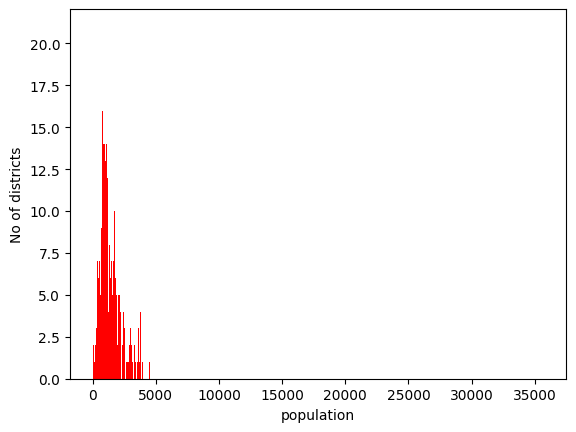

In [65]:
# plotting num_districts vs population that depicts heavy-tail distribution clearly
population_numdistrics = dict(housing['population'].value_counts())
plt.bar(x=list(population_numdistrics.keys()),height=list(population_numdistrics.values()),width=1.0,color='red')
plt.xlabel('population')
plt.ylabel('No of districts')
plt.show()

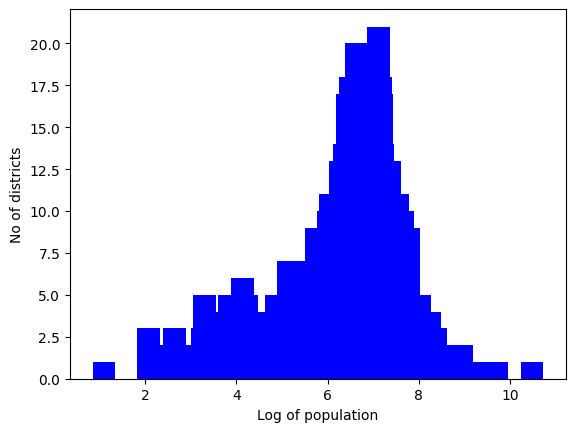

In [66]:
# performing conversion of heavy-tailed distribution above to normal distribution by taking logarithm of values.
x_vals = [np.log(val) for val in population_numdistrics.keys()]
plt.bar(x=x_vals,height=list(population_numdistrics.values()),width=0.5,color='blue')
plt.xlabel('Log of population')
plt.ylabel('No of districts')
plt.show()

### TRANSFORMING FEATURE WITH MULTIMODAL DISTRIBUTION
To handle multimodal feature distribution usually the following approaches are considered,
1. **Bucketising** using the bucket ID as category and not as numerical value.
2. Using **RBF(Radial Basis Function)** for the main modes. **RBF** measures the radial distance between an input and a fixed value. Usually **Gaussian RBF** is used which is **exp(-c(X-Y)^2)** where Y => a vector.

Text(0, 0.5, 'No of districts')

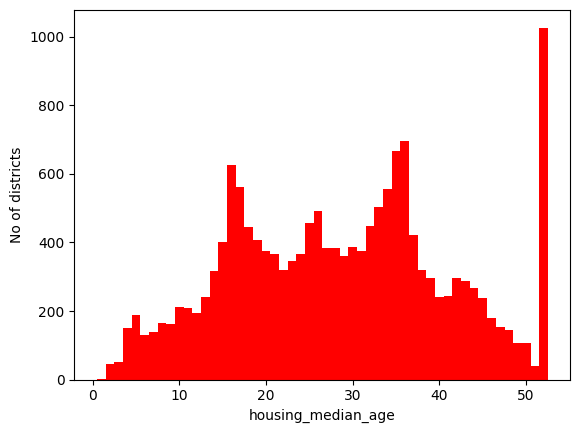

In [67]:
# housing_median_age distribution represents a multimodal distribution.
housing_median_age_dist = dict(housing['housing_median_age'].value_counts())
plt.bar(x=list(housing_median_age_dist.keys()),height=list(housing_median_age_dist.values()),width=1.0,color='red')
plt.xlabel('housing_median_age')
plt.ylabel('No of districts')

In [68]:
# perform RBF for some of the main modes above
from sklearn.metrics.pairwise import rbf_kernel

In [69]:
age_simil_35 = rbf_kernel(housing[['housing_median_age']],[[35]],gamma=0.1)

In [70]:
housing['Age_similarity'] = age_simil_35

In [71]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,Age_similarity
12655,-121.46,38.52,29,3873,797.0,2237,706,2.1736,INLAND,2.732372e-02
15502,-117.23,33.09,7,5320,855.0,2015,768,6.3373,NEAR OCEAN,8.939487e-35
2908,-119.04,35.37,44,1618,310.0,667,300,2.8750,INLAND,3.035391e-04
14053,-117.13,32.75,24,1877,519.0,898,483,2.2264,NEAR OCEAN,5.559513e-06
20496,-118.70,34.28,27,3536,646.0,1837,580,4.4964,<1H OCEAN,1.661557e-03


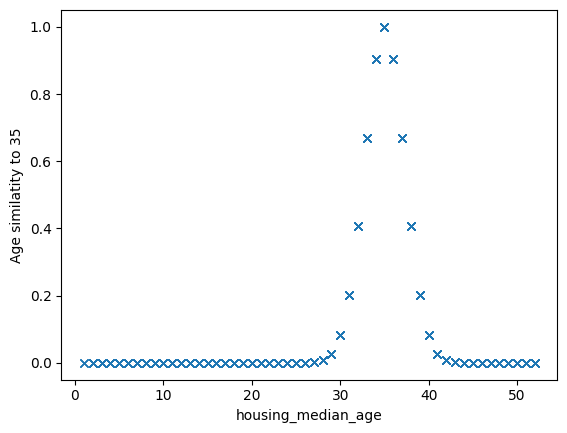

In [72]:
#plot rbf
plt.plot(housing['housing_median_age'],housing['Age_similarity'],'x')
plt.xlabel('housing_median_age')
plt.ylabel('Age similatity to 35')
plt.show()

### TRANSFORMING LABEL
The label/target may require transforming just as the input features. For instance if the target has **heavy-tailed** distribution or a short-range needing **scaling** like we observed previously in case of the inputs we may as well
apply the same method used earlier but then the ML model's output will indicate this transformed result which needs an inverse of the operation performed to come out with the actual outcome desired.

Most of Sci-kit Learmn's transformers provides an **inverse_transform()** method for the same.

The following code shows how we scale labels before feeding to a ML model and then subsequently on the output we apply inverse transform to obtain result as desired.

In [73]:
housing.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity', 'Age_similarity'],
      dtype='object')

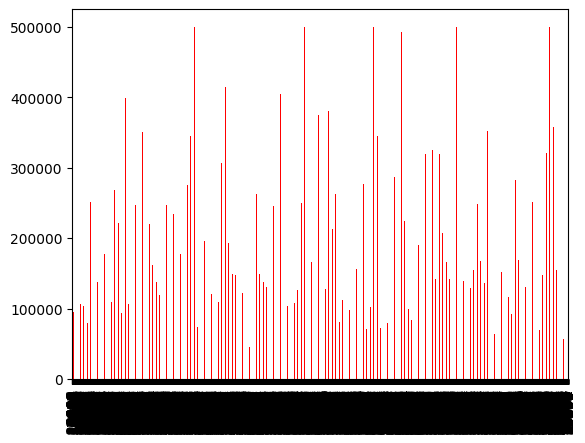

In [74]:
housing_label_dict = dict(housing_label.value_counts())
housing_label_x = list(housing_label_dict.keys())
housing_label_y = list(housing_label_dict.values())
housing_label.plot(kind='bar',x=housing_label_x,y=housing_label_y,width=0.2,color='red')
plt.show()

In [75]:
from sklearn.linear_model import LinearRegression

target_scaler = StandardScaler()
scaled_labels = target_scaler.fit_transform(housing_label.to_frame())

model = LinearRegression()
model.fit(housing[['median_income']],scaled_labels)
some_new_data = housing[['median_income']].iloc[:5] #consider this to be new data

scaled_predictions = model.predict(some_new_data)
predictions = target_scaler.inverse_transform(scaled_predictions)

Another simpler option is to use a **TransformedTargetRegressor** passing the regression model & the label transformer. Then fit it on the training set using original unscaled labels. It automatically scales the labels 
and train the regression model on the scaled labels. Then on using **predict()** it'll call the model's predict method and auto convert the scaled predictions using **inverse_transform()**.

In [76]:
from sklearn.compose import TransformedTargetRegressor

model = TransformedTargetRegressor(LinearRegression(),transformer=StandardScaler())
model.fit(housing[['median_income']],housing_label)
predictions_on_trtgtreg = model.predict(some_new_data)

In [77]:
predictions[:5],predictions_on_trtgtreg[:5]

(array([[135958.75805364],
        [309735.008975  ],
        [165232.3998617 ],
        [138162.41971241],
        [232903.1766333 ]]),
 array([135958.75805364, 309735.008975  , 165232.3998617 , 138162.41971241,
        232903.1766333 ]))

### CUSTOM TRANSFORMERS
For tasks that needs custom transformations outside Scikit-Learn's scope one may have to write their own. 

For transformations that don't require training one may write a function that considers numpy array as input & output the transformed array. 

Here we transform features with **heavy-tailed** distribution (assuming the tail is to the right & values are positive).

In [78]:
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log,inverse_func=np.exp)
log_pop = log_transformer.transform(housing[['population']])

Below we create a transformer that computes **Gaussian RBF** similarity measure.

In [79]:
rbf_transformer = FunctionTransformer(rbf_kernel,kw_args=dict(Y=[[35.]],gamma=0.1))
age_simil_35_using_func_trans = rbf_transformer.transform(housing[['housing_median_age']])

The below code measures geographic similarity between each district & San Francisco. 

Here the RBF kernel considers a 2D Y-vector.

In [80]:
sf_coords = 37.7749,-122.41
sf_transformer = FunctionTransformer(rbf_kernel,kw_args=dict(Y=[sf_coords],gamma=0.1))
sf_simil = sf_transformer.transform(housing[['latitude','longitude']])

### CREATE CUSTOMISED FUNCTION TRANSFORMER
Customised function transformer is useful in the sense one can train it to learn some parameters in **fit()** & then use those in **transform()** method. 

Use of **BaseEstimator** & **TransformerMixin** classes lets one use **set_params()**,**get_params()** & **fit_transform()** directly.

In [81]:
from sklearn.base import BaseEstimator,TransformerMixin
from sklearn.utils.validation import check_array,check_is_fitted
from sklearn.cluster import KMeans

In [82]:
class ClusterSimilarity(BaseEstimator,TransformerMixin):
    def __init__(self,gamma,n_clusters,random_state=None):
        super().__init__()
        self.gamma = gamma
        self.random_state = random_state
        self.n_clusters = n_clusters
    
    def fit(self,X,y=None,sample_weight=None):
        # check if input array passed contains finite float values & if contains dtype 'object' raises any failed attempt to convert it to numeric.
        X = check_array(X)
        self.k_means_ = KMeans(n_clusters=self.n_clusters,random_state=self.random_state)
        self.k_means_.fit(X=X,sample_weight=sample_weight)
        self.n_features_in_ = X.shape[1]
        return self
    
    def transform(self,X):
        # check if input array passed contains finite float values & if contains dtype 'object' raises any failed attempt to convert it to numeric.
        X = check_array(X)

        # check if transformer object has learned parameters to transform X
        check_is_fitted(self)

        # check if the data on which transformation is to be applied has same attributes as the input it is trained on
        assert self.n_features_in_ == X.shape[1]

        # measure to check how similar each sample is to each cluster centre
        return rbf_kernel(X,self.k_means_.cluster_centers_,gamma=self.gamma)
    
    def get_feature_names_out(self,names=None):
        return [f'Cluster {i} similarity' for i in range(self.n_clusters)]

In [83]:
cluster_simil = ClusterSimilarity(1.,10,42)
similarities = cluster_simil.fit_transform(housing[['latitude','longitude']],sample_weight = housing_label)

In [84]:
similarities[:3].round(2)

array([[0.31, 0.  , 0.  , 0.9 , 0.  , 0.01, 0.  , 0.17, 0.  , 0.  ],
       [0.  , 0.12, 0.94, 0.  , 0.  , 0.  , 0.  , 0.  , 0.42, 0.  ],
       [0.  , 0.1 , 0.  , 0.  , 0.43, 0.  , 0.11, 0.  , 0.02, 0.1 ]])

In [85]:
cluster_centres = cluster_simil.k_means_.cluster_centers_
for x,y in cluster_centres[:5]:
    print(x,y)

37.87982656414673 -122.3364448779988
34.049297986235416 -118.31142521510847
32.94169660836274 -117.03870480001642
38.46136419879829 -121.14595713819271
34.48737440039951 -119.29730909752531


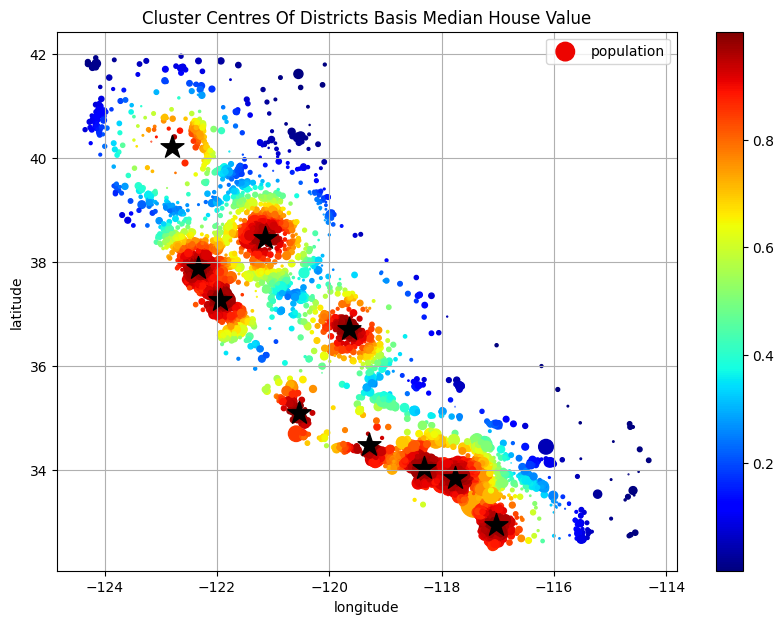

In [86]:
ax = housing.plot(kind='scatter',x='longitude',y='latitude',grid=True,s=housing['population']/100,c=np.max(similarities,axis=1),colormap='jet',colorbar=True,legend=True,figsize=(10,7),sharex=False,label='population')

# marks cluster centres on the scatter plot
cluster_centres = cluster_simil.k_means_.cluster_centers_
for lon,lat in cluster_centres:
    ax.scatter(lat,lon,color='black',marker='*',s=300)

ax.set_title('Cluster Centres Of Districts Basis Median House Value')
plt.show()

### TRANSFORMATION PIPELINE
There exists numerous data transformation steps that needs execution in the right order before data can be fed to a ML model. For this Scikit Learn provides **Pipelines**.

In [87]:
from sklearn.pipeline import Pipeline

In [88]:
num_pipeline = Pipeline([
    ('impute',SimpleImputer(strategy='median')),
    ('standardise',StandardScaler())
])

In [89]:
num_pipeline

Pipeline(steps=[('impute', SimpleImputer(strategy='median')),
                ('standardise', StandardScaler())])

In [90]:
housing_num_prepared = num_pipeline.fit_transform(housing_num)
housing_num_prepared[:2].round(2)

array([[-0.94,  1.35,  0.03,  0.58,  0.64,  0.73,  0.56, -0.89],
       [ 1.17, -1.19, -1.72,  1.26,  0.78,  0.53,  0.72,  1.29]])

In [91]:
df_housing_num_prepared = pd.DataFrame(housing_num_prepared,columns=num_pipeline.get_feature_names_out(),index=housing_num.index)

In [92]:
df_housing_num_prepared.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
12655,-0.941350,1.347438,0.027564,0.584777,0.640371,0.732602,0.556286,-0.893647
15502,1.171782,-1.192440,-1.722018,1.261467,0.781561,0.533612,0.721318,1.292168
2908,0.267581,-0.125972,1.220460,-0.469773,-0.545138,-0.674675,-0.524407,-0.525434
14053,1.221738,-1.351474,-0.370069,-0.348652,-0.036367,-0.467617,-0.037297,-0.865929
20496,0.437431,-0.635818,-0.131489,0.427179,0.272790,0.374060,0.220898,0.325752


### DEFINING TRANSFORMER TO HANDLE ALL DATATYPES COLUMNS
So far we handled numerical & categorical attributes seperately. 

Here we define a single transformer that applies appropriate transformations to attributes depending on datatypes.

In [93]:
from sklearn.compose import ColumnTransformer

In [94]:
housing.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity', 'Age_similarity'],
      dtype='object')

In [95]:
num_attribs = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income']

cat_attribs = ['ocean_proximity']

In [96]:
from sklearn.pipeline import make_pipeline

In [97]:
cat_pipeline = make_pipeline(SimpleImputer(strategy='most_frequent'),
                             OneHotEncoder(handle_unknown='ignore'))

preprocessing = ColumnTransformer([
    ("num",num_pipeline,num_attribs),
    ('cat',cat_pipeline,cat_attribs)
])

Above columns not listed are by default "dropped". One can otherwise explicitly mention "drop"/"passthrough" to either drop the columns or keep the columns untouched 
by the transformer. 

Similar to "make_pipeline" which chooses the transformer name by itself "make_column_transformer" does the same. 

Also one can use "make_column_selector" to choose columns rather than listing columns which isn't very convenient.

In [98]:
from sklearn.compose import make_column_selector,make_column_transformer

In [99]:
preprocessing = make_column_transformer(
    (num_pipeline,make_column_selector(dtype_include=np.number)),
    (cat_pipeline,make_column_selector(dtype_include=object))
)

In [100]:
housing_prepared = preprocessing.fit_transform(housing)

In [101]:
housing.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity', 'Age_similarity'],
      dtype='object')

In [102]:
def column_ratio(X):
    return X[:,[0]]/X[:,[1]]

def ratio_name(function_transformer,feature_names_in):
    return ["ratio"]

ratio_pipeline = make_pipeline(
        SimpleImputer(strategy='median'),
        FunctionTransformer(column_ratio,feature_names_out=ratio_name),
        StandardScaler()
    )

log_pipeline = make_pipeline(
        SimpleImputer(strategy='median'),
        FunctionTransformer(np.log,feature_names_out='one-to-one'),
        StandardScaler()
    )

cluster_simil = ClusterSimilarity(n_clusters=10,gamma=1.,random_state=42)
default_num_pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

In [103]:
preprocessing = ColumnTransformer([
    ('bedrooms',ratio_pipeline,['total_bedrooms','total_rooms']),
    ('rooms_per_house',ratio_pipeline,['total_rooms','households']),
    ('people_per_house',ratio_pipeline,['population','households']),
    ('log',log_pipeline,['total_bedrooms','total_rooms','households','population','median_income']),
    ('geo',cluster_simil,['longitude', 'latitude']),
    ('cat',cat_pipeline,make_column_selector(dtype_include=object))
],
remainder=default_num_pipeline)

In [104]:
housing_prepared = preprocessing.fit_transform(housing)
housing_prepared.shape

(16512, 25)

In [105]:
preprocessing.get_feature_names_out()

array(['bedrooms__ratio', 'rooms_per_house__ratio',
       'people_per_house__ratio', 'log__total_bedrooms',
       'log__total_rooms', 'log__households', 'log__population',
       'log__median_income', 'geo__Cluster 0 similarity',
       'geo__Cluster 1 similarity', 'geo__Cluster 2 similarity',
       'geo__Cluster 3 similarity', 'geo__Cluster 4 similarity',
       'geo__Cluster 5 similarity', 'geo__Cluster 6 similarity',
       'geo__Cluster 7 similarity', 'geo__Cluster 8 similarity',
       'geo__Cluster 9 similarity', 'cat__ocean_proximity_<1H OCEAN',
       'cat__ocean_proximity_INLAND', 'cat__ocean_proximity_ISLAND',
       'cat__ocean_proximity_NEAR BAY', 'cat__ocean_proximity_NEAR OCEAN',
       'remainder__housing_median_age', 'remainder__Age_similarity'],
      dtype=object)

### SELECT AND TRAIN MODEL

In [110]:
lin_reg = make_pipeline(preprocessing,LinearRegression())
lin_reg.fit(housing,housing_label)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x33a...
                                                 ('geo',
                                                  ClusterSimilarity(gamma=1.0,
                                                                    n_clusters=10,
                                                                    random_state=42),
                                                  ['longitude', 'latitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x3392faa10>)])),
                ('linearregression', LinearRegression())])

In [111]:
housing_predictions = lin_reg.predict(housing)
housing_predictions[:5].round(-2)

array([ 66600., 289000., 187300., 191300., 273400.])

In [112]:
housing_label.iloc[:5].values

array([ 72100, 279600,  82700, 112500, 238300])

In [113]:
from sklearn.metrics import mean_squared_error,root_mean_squared_error

In [114]:
lin_rmse = root_mean_squared_error(housing_label,housing_predictions)

In [115]:
lin_rmse

68964.54276581958

From above we observe that it's RMSE is at $69123. The typical median house price for any district ranges between $120000 and $265000 hence this prediction is not right. 

This prediction shows that model has **underfitted** the training data. 

This could be attributed to several factors such as,
1. Model is too simple
2. The features fed to the model do not capture the true underlying pattern
3. Model contraints are too tight. 

Since the model was not regularised we rule out the third option. 

Now we go for a more complex model to see how it performs before feeding the model more features to better capture the data pattern.

In [116]:
from sklearn.tree import DecisionTreeRegressor

In [117]:
tree_rig = make_pipeline(preprocessing,DecisionTreeRegressor(random_state=42))
tree_rig.fit(housing,housing_label)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x33a...
                                                  ClusterSimilarity(gamma=1.0,
                                                                    n_clusters=10,
                                                                    random_state=42),
                                                  ['longitude', 'latitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x3392faa10>)])),
                ('decisiontreeregressor',
                 DecisionTreeRegressor(random_state=42))])

In [118]:
housing_predictions_tree = tree_rig.predict(housing)
tree_rmse = root_mean_squared_error(housing_label,housing_predictions_tree)

In [119]:
tree_rmse

0.0

The above result even though astonishing may be due to model badly overfitting the data. It happens when model has knowledge about the dataset it is tested on 
hence it is usually advisable not to use the test set until one is confident about model's performance. 

Usually the train-set is divided into a smaller train-set and validation-set. The latter is used for model evaluation. 

Below we use the **K-Fold Cross-Validation** method to evaluate model performance.

### USING K-FOLD CV TO EVALUATE MODEL PERFORMANCE

In [120]:
from sklearn.model_selection import cross_val_score

Scikit-Learn's **Cross-validation** expects a *utility-function*(greater is better) rather than a *cost-function*(lower is better) hence the scoring function used is actually 
the opposite of RMSE. Since it's a negative value one needs to switch the output to get the RMSE scores.

In [121]:
tree_rmse = -cross_val_score(tree_rig,housing,housing_label,scoring='neg_root_mean_squared_error',cv=10)

In [122]:
pd.Series(tree_rmse).describe()

count       10.000000
mean     66900.421293
std       3124.784579
min      61627.492959
25%      65023.192027
50%      67106.089801
75%      68082.252041
max      72030.946421
dtype: float64

Now we try one last model **RandomForestRegressor**.

In [123]:
from sklearn.ensemble import RandomForestRegressor

In [124]:
forest_reg = make_pipeline(preprocessing,RandomForestRegressor(random_state=42))
forest_rmses = -cross_val_score(forest_reg,housing,housing_label,scoring='neg_root_mean_squared_error',cv=10)

In [125]:
pd.Series(forest_rmses).describe()

count       10.000000
mean     47371.257183
std       2453.338001
min      43896.655483
25%      45156.590520
50%      47631.294653
75%      49226.531039
max      50967.879859
dtype: float64

### GRID SEARCH CV
Suppose one has a shortlist of promising models and they need fine-tuning of hyperparameters. One way to do just that is using **Grid Search CV**. 

In here one just has to tell what the hyperparameters are and what values it can take. Scikit-learn performs Cross-validation to evaluate all possible combinations of the
values on the respective hyperparameters.

In [126]:
from sklearn.model_selection import GridSearchCV

In [127]:
full_pipeline = Pipeline([
    ("preprocessing",preprocessing),
    ("random_forest",RandomForestRegressor(random_state=42))
])

param_grid = [
    {'preprocessing__geo__n_clusters':[5,8,10],
     'random_forest__max_features':[4,6,8]},
     {'preprocessing__geo__n_clusters':[10,15],
     'random_forest__max_features':[6,8,10]}
]

grid_search = GridSearchCV(full_pipeline,param_grid,cv=3,scoring='neg_root_mean_squared_error')
grid_search.fit(housing,housing_label)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                     SimpleImputer(strategy='median')),
                                                                                    ('standardscaler',
                                                                                     StandardScaler())]),
                                                          transformers=[('bedrooms',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('functiontransformer',
                                                                                          FunctionTransformer(feature_names_out=<f...
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x3392faa10>)])),
                                       ('random_forest',
                                        RandomForestRegressor(random_state=42))]),
             param_grid=[{'preprocessing__geo__n_clusters': [5, 8, 10],
                          'random_forest__max_features': [4, 6, 8]},
                         {'preprocessing__geo__n_clusters': [10, 15],
                          'random_forest__max_features': [6, 8, 10]}],
             scoring='neg_root_mean_squared_error')

In [128]:
grid_search.best_params_

{'preprocessing__geo__n_clusters': 15, 'random_forest__max_features': 6}

In [129]:
cv_res = pd.DataFrame(grid_search.cv_results_)
cv_res.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_preprocessing__geo__n_clusters,param_random_forest__max_features,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,2.346983,0.077574,0.089880,0.001721,5,4,"{'preprocessing__geo__n_clusters': 5, 'random_...",-47665.601822,-47772.871984,-48978.761825,-48139.078544,595.358565,14
1,3.311681,0.090729,0.088969,0.000197,5,6,"{'preprocessing__geo__n_clusters': 5, 'random_...",-47184.790562,-47461.806131,-49077.172270,-47907.922987,834.482802,13
2,4.231966,0.114281,0.089127,0.000398,5,8,"{'preprocessing__geo__n_clusters': 5, 'random_...",-47429.114900,-47763.569851,-49506.989520,-48233.224757,910.978423,15
3,2.368496,0.026654,0.088587,0.000307,8,4,"{'preprocessing__geo__n_clusters': 8, 'random_...",-45698.136254,-46125.904825,-47150.076890,-46324.705990,609.193089,11
4,3.318027,0.063394,0.088482,0.000148,8,6,"{'preprocessing__geo__n_clusters': 8, 'random_...",-45433.837849,-46077.436608,-47219.607878,-46243.627445,738.448010,10


In [130]:
cv_res['mean_test_rmse'] = -cv_res['mean_test_score']
cv_res.drop(columns=['mean_test_score'],inplace=True)
cv_res.sort_values(by=['mean_test_rmse'],inplace=True)
cv_res.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_preprocessing__geo__n_clusters,param_random_forest__max_features,params,split0_test_score,split1_test_score,split2_test_score,std_test_score,rank_test_score,mean_test_rmse
12,3.376519,0.028927,0.089388,0.000281,15,6,"{'preprocessing__geo__n_clusters': 15, 'random...",-43368.025439,-44454.120061,-45090.414442,711.109926,1,44304.186647
13,4.361760,0.047258,0.088858,0.000047,15,8,"{'preprocessing__geo__n_clusters': 15, 'random...",-43861.864066,-44636.188705,-45692.598661,750.345831,2,44730.217144
14,5.351413,0.076343,0.089569,0.000080,15,10,"{'preprocessing__geo__n_clusters': 15, 'random...",-44206.471515,-44947.347172,-46081.868059,771.228931,3,45078.562249
7,3.285120,0.064363,0.089313,0.000908,10,6,"{'preprocessing__geo__n_clusters': 10, 'random...",-44375.061697,-45470.655216,-46302.727552,789.413649,4,45382.814821
9,3.299214,0.066877,0.088942,0.000367,10,6,"{'preprocessing__geo__n_clusters': 10, 'random...",-44375.061697,-45470.655216,-46302.727552,789.413649,4,45382.814821


In [131]:
cv_res.rename(columns={
    'split0_test_score':'split0',
    'split1_test_score':'split1',
    'split2_test_score':'split2',
    'param_preprocessing__geo__n_clusters':'n_clusters',
    'param_random_forest__max_features':'max_features'
},inplace=True)

In [132]:
cv_res[['split0','split1','split2','n_clusters','max_features','mean_test_rmse']]

,split0,split1,split2,n_clusters,max_features,mean_test_rmse
12,-43368.025439,-44454.120061,-45090.414442,15,6,44304.186647
13,-43861.864066,-44636.188705,-45692.598661,15,8,44730.217144
14,-44206.471515,-44947.347172,-46081.868059,15,10,45078.562249
7,-44375.061697,-45470.655216,-46302.727552,10,6,45382.814821
9,-44375.061697,-45470.655216,-46302.727552,10,6,45382.814821
6,-44460.578378,-45452.778397,-46396.935511,10,4,45436.764095
8,-44889.233147,-45722.003895,-46589.689769,10,8,45733.642270
10,-44889.233147,-45722.003895,-46589.689769,10,8,45733.642270
11,-45422.026766,-46033.413418,-47173.083706,10,10,46209.507963
4,-45433.837849,-46077.436608,-47219.607878,8,6,46243.627445


### RANDOMIZED SEARCH
**Grid Search CV** works well when exploring hyperparameters with small search space but **Random Search CV** works well when search space is quite large. 

In **Random search CV** for every hyperparameter random values are picked and tested every iteration. So if suppose there exists n hyperparameters with y values each then **Grid Search CV** will train the model y^n times whereas **Random search CV** will train it for x times where x is the number of iterations. 

Also if one doesn't know whether a particular hyperparameter is important for the model and say it has 10 different values then testing for it via **Grid search CV** will need 10 times longer the time as compared to **Random search CV**.

In [133]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

There also exists **HalvingRandomSearchCV** & **HalvingGridSearchCV** that uses computational resources more efficiently to achieve,
1. Faster training or,
2. Explore larger hyperparameter space

In [134]:
param_distribs = {
    'preprocessing__geo__n_clusters':randint(low=3,high=50),
    'random_forest__max_features':randint(low=2,high=20)
}

rnd_search = RandomizedSearchCV(full_pipeline,param_distribs,n_iter=10,cv=3,scoring='neg_root_mean_squared_error',random_state=42)
rnd_search.fit(housing,housing_label)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                           SimpleImputer(strategy='median')),
                                                                                          ('standardscaler',
                                                                                           StandardScaler())]),
                                                                transformers=[('bedrooms',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('functiontransformer',
                                                                                                FunctionTransformer(feature_names_...
                                                                               <sklearn.compose._column_transformer.make_column_selector object at 0x3392faa10>)])),
                                             ('random_forest',
                                              RandomForestRegressor(random_state=42))]),
                   param_distributions={'preprocessing__geo__n_clusters': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x34bd2fe80>,
                                        'random_forest__max_features': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x34bd2fe50>},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [135]:
rand_cv_results = pd.DataFrame(rnd_search.cv_results_)
rand_cv_results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_preprocessing__geo__n_clusters,param_random_forest__max_features,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,8.402007,0.120729,0.135041,0.005567,41,16,"{'preprocessing__geo__n_clusters': 41, 'random...",-42589.826343,-43937.729332,-44467.960550,-43665.172075,790.595817,5
1,4.916111,0.078210,0.137192,0.010583,45,9,"{'preprocessing__geo__n_clusters': 45, 'random...",-41708.728126,-42989.320889,-43160.765937,-42619.604984,647.879021,1
2,4.359710,0.067159,0.089183,0.000622,23,8,"{'preprocessing__geo__n_clusters': 23, 'random...",-42608.523169,-43771.175822,-44123.587489,-43501.095493,647.334283,4
3,6.346295,0.083405,0.089632,0.000426,21,12,"{'preprocessing__geo__n_clusters': 21, 'random...",-43695.545221,-44557.849632,-45747.533075,-44666.975976,841.266885,9
4,2.852712,0.040914,0.088899,0.000168,13,5,"{'preprocessing__geo__n_clusters': 13, 'random...",-43708.093813,-44511.382710,-45267.459576,-44495.645366,636.705659,8


In [136]:
rand_cv_results['mean_test_rmse'] = -rand_cv_results['mean_test_score']
rand_cv_results.drop(columns=['mean_test_score'],inplace=True)
rand_cv_results.sort_values(by=['mean_test_rmse'],inplace=True)

rand_cv_results.rename(columns={
    'split0_test_score':'split0',
    'split1_test_score':'split1',
    'split2_test_score':'split2',
    'param_preprocessing__geo__n_clusters':'n_clusters',
    'param_random_forest__max_features':'max_features'
},inplace=True)

In [137]:
rand_cv_results[['split0','split1','split2','n_clusters','max_features','mean_test_rmse']]

,split0,split1,split2,n_clusters,max_features,mean_test_rmse
1,-41708.728126,-42989.320889,-43160.765937,45,9,42619.604984
8,-42112.208640,-43663.706098,-43660.558163,32,7,43145.490967
5,-42109.843669,-44175.759865,-43581.901954,42,4,43289.168496
2,-42608.523169,-43771.175822,-44123.587489,23,8,43501.095493
0,-42589.826343,-43937.729332,-44467.960550,41,16,43665.172075
6,-42884.849654,-44766.325999,-44838.362650,24,3,44163.179434
7,-43703.570638,-43922.981857,-44929.057264,26,13,44185.203253
4,-43708.093813,-44511.382710,-45267.459576,13,5,44495.645366
3,-43695.545221,-44557.849632,-45747.533075,21,12,44666.975976
9,-50415.550733,-51411.990457,-52455.547118,4,2,51427.696103


### ENSEMBLE METHODS
Another way to fine-tune model is to try and combine models that perform best. The group will often perform best that the best individual model similar to how random forests perform better than the individual decision trees they rely on more so when individual models make different types of errors.

### ANALYSE THE BEST MODELS AND THEIR ERRORS
Often one gets good insights on the problem by analusing the best models. 

For instance the **RandomForestRegressor** can highlight the importance of each attribute towards making accurate predictions.

In [138]:
final_model = rnd_search.best_estimator_
feature_importances = final_model["random_forest"].feature_importances_
feature_importances.round(2)

array([0.07, 0.05, 0.05, 0.01, 0.01, 0.01, 0.01, 0.18, 0.01, 0.01, 0.02,
       0.01, 0.01, 0.01, 0.04, 0.01, 0.  , 0.01, 0.01, 0.02, 0.01, 0.02,
       0.  , 0.02, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.02,
       0.01, 0.01, 0.01, 0.01, 0.02, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.  , 0.01, 0.  , 0.03, 0.01, 0.01, 0.07,
       0.  , 0.  , 0.  , 0.01, 0.  ])

We arrange the numbers above in descending order and map them to their attributes and maybe then we can drop the ones which are less important.

In [139]:
sorted(zip(feature_importances,final_model['preprocessing'].get_feature_names_out()),reverse=True)

[(0.1838497158426082, 'log__median_income'),
 (0.0708919827885981, 'bedrooms__ratio'),
 (0.06656625979657306, 'cat__ocean_proximity_INLAND'),
 (0.05452821861956236, 'rooms_per_house__ratio'),
 (0.045899535851336395, 'people_per_house__ratio'),
 (0.03748731224057325, 'geo__Cluster 6 similarity'),
 (0.03217501733307975, 'geo__Cluster 43 similarity'),
 (0.024392465882748512, 'geo__Cluster 11 similarity'),
 (0.02223027726458734, 'geo__Cluster 2 similarity'),
 (0.019784354618716825, 'geo__Cluster 15 similarity'),
 (0.01784669773848354, 'geo__Cluster 24 similarity'),
 (0.016876626458681106, 'geo__Cluster 13 similarity'),
 (0.01524287218757446, 'geo__Cluster 29 similarity'),
 (0.014759901998105916, 'geo__Cluster 0 similarity'),
 (0.01455612983489827, 'geo__Cluster 10 similarity'),
 (0.014076322568639438, 'geo__Cluster 30 similarity'),
 (0.014050378980446365, 'geo__Cluster 1 similarity'),
 (0.013205648405072865, 'geo__Cluster 26 similarity'),
 (0.01253491476324319, 'geo__Cluster 33 similarity'

### EVALUATE MODEL ON TEST SET

In [143]:
strat_test_set['Age_similarity'] = rbf_kernel(strat_test_set[['housing_median_age']],[[35]],gamma=0.1)

/var/folders/_d/d0_pf6hn3t5gl_r_tykfvcxh0000gn/T/ipykernel_8523/3432509821.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  strat_test_set['Age_similarity'] = rbf_kernel(strat_test_set[['housing_median_age']],[[35]],gamma=0.1)


In [144]:
strat_test_set.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity', 'median_house_value', 'Age_similarity'],
      dtype='object')

In [145]:
X_test = strat_test_set.drop('median_house_value',axis=1)
y_test = strat_test_set['median_house_value'].copy()

final_predictions = final_model.predict(X_test)

final_rmse = root_mean_squared_error(y_test,final_predictions)
print(f"Final RMSE is {final_rmse}")

Final RMSE is 39603.44837631112


### CONFIDENCE INTERVAL
Such point estimate may not be enough to push model to production. What if it's just 0.1% better than the model that currently sits in production. 

Under such cases we make use of confidence intervals (CI) which gives a fair estimate of what the range will be most of the time w.r.t the RMSE. 

A 95% CI says that if data is sampled over numerous times then 95% of the time will we get the true population parameter (prediction) within the interval computed. 

CI = point_estimate +- z * SE where SE -> Standard Error = SD/sqrt(n) where SD: std-deviation, n: sample-size 

Usually the narrower the range the better is the estimate such that even with sampling done several times over the true population parameter is likely to fall within the range.

In [146]:
from scipy import stats

In [147]:
confidence = 0.95
squared_errors = (final_predictions - y_test)**2
np.sqrt(stats.t.interval(confidence,len(squared_errors)-1,loc=squared_errors.mean(),scale = stats.sem(squared_errors)))

array([37742.57924098, 41380.71965093])

As can be observed above the rnage is indeed quite large and hence the **generalisation error** is perhaps not that good enough.